In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter


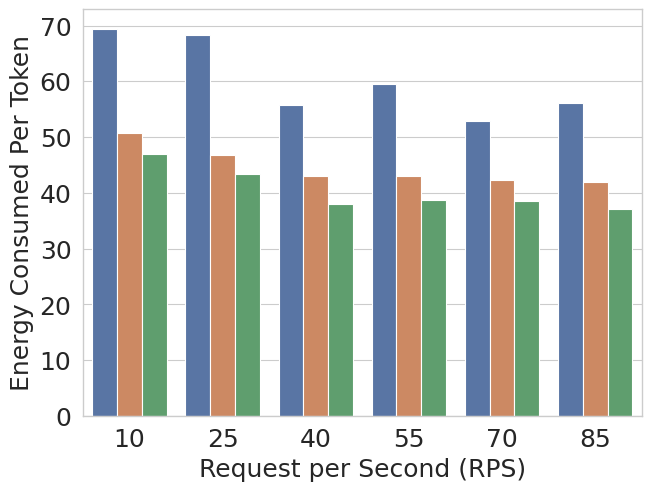

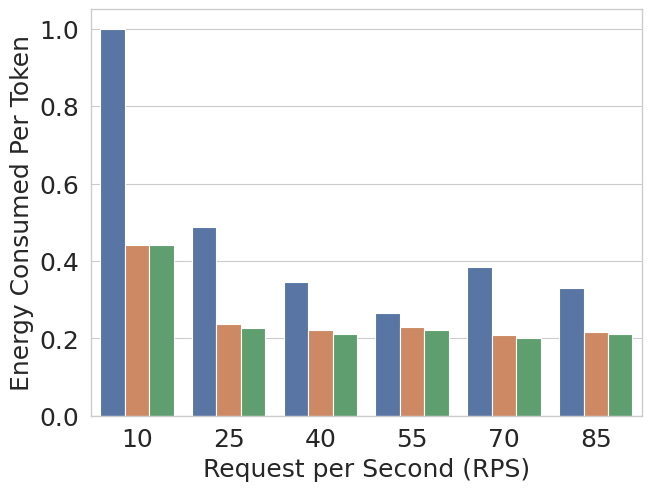

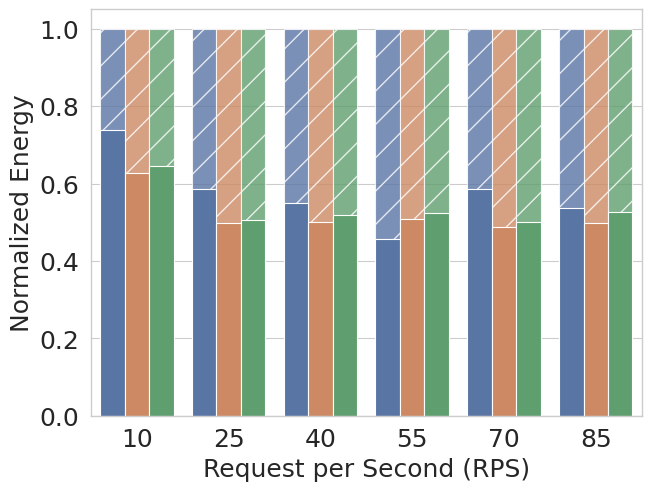

In [11]:
path = "/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/synthetic_char_balance/metrics.csv"
df_results = pd.read_csv(path)

# Create a mapping for renaming expr_dir values
rename_mapping = {
    'DISTSERVE_R5_JAN3_B5_1': 'Distserve 85',
    'DISTSERVE_R5_JAN3_B5_2': 'Distserve 70',
    'DISTSERVE_R5_JAN3_B5_3': 'Distserve 55',
    'DISTSERVE_R5_JAN3_B5_4': 'Distserve 40',
    'DISTSERVE_R5_JAN3_B5_5': 'Distserve 25',
    'DISTSERVE_R5_JAN3_B5_6': 'Distserve 10',
    'OURS_R5_JAN3_B5_1': 'Min Energy 85',
    'OURS_R5_JAN3_B5_2': 'Min Energy 70',
    'OURS_R5_JAN3_B5_3': 'Min Energy 55',
    'OURS_R5_JAN3_B5_4': 'Min Energy 40',
    'OURS_R5_JAN3_B5_5': 'Min Energy 25',
    'OURS_R5_JAN3_B5_6': 'Min Energy 10',
    'OURS_R5_JAN3_B5_1_DVFS': 'Min Energy + DVFS 85',
    'OURS_R5_JAN3_B5_2_DVFS': 'Min Energy + DVFS 70',
    'OURS_R5_JAN3_B5_3_DVFS': 'Min Energy + DVFS 55',
    'OURS_R5_JAN3_B5_4_DVFS': 'Min Energy + DVFS 40',
    'OURS_R5_JAN3_B5_5_DVFS': 'Min Energy + DVFS 25',
    'OURS_R5_JAN3_B5_6_DVFS': 'Min Energy + DVFS 10',
    'OURS_R5_JAN3_B5_1_DVFS_W': 'Min Energy + DVFS 85',
    'OURS_R5_JAN3_B5_2_DVFS_W': 'Min Energy + DVFS 70',
    'OURS_R5_JAN3_B5_3_DVFS_W': 'Min Energy + DVFS 55',
    'OURS_R5_JAN3_B5_4_DVFS_W': 'Min Energy + DVFS 40',
    'OURS_R5_JAN3_B5_5_DVFS_W': 'Min Energy + DVFS 25',
    'OURS_R5_JAN3_B5_6_DVFS_W': 'Min Energy + DVFS 10',
}

df_results = df_results[~df_results['expr_dir'].isin([
    'OURS_R5_JAN3_B5_6_DVFS', 'OURS_R5_JAN3_B5_5_DVFS',
    'OURS_R5_JAN3_B5_4_DVFS', 'OURS_R5_JAN3_B5_3_DVFS',
    'OURS_R5_JAN3_B5_2_DVFS', 'OURS_R5_JAN3_B5_1_DVFS'
])]
# Replace values in expr_dir column
df_results['expr_dir'] = df_results['expr_dir'].replace(rename_mapping)

df_results = df_results[df_results["instance"] == "total"]

# Sort the dataframe by extracting the numeric suffix from expr_dir
df_results['sort_key'] = df_results['expr_dir'].str.extract('(\d+)$')[0].fillna(0).astype(int)
df_results = df_results.sort_values('sort_key')

# Extract RPS and name from expr_dir
df_results['rps'] = df_results['expr_dir'].str.extract('(\d+)$')[0].astype(int)
df_results['name'] = df_results['expr_dir'].str.replace('\s+\d+$', '', regex=True)

# Set the order of the categories
df_results['name'] = pd.Categorical(df_results['name'], categories=['Distserve', 'Min Energy', 'Min Energy + DVFS'], ordered=True)
df_results = df_results.sort_values(['rps', 'name'])

sns.set_theme(context="paper", style="whitegrid")
plt.figure(constrained_layout=True)
ax = sns.barplot(
    x="rps", 
    y="prefill_energy_per_token", 
    hue="name", 
    data=df_results, 
    dodge=True,
    # hatch='/', # Add hatch pattern to the bars
    # alpha=0.8,       # Lighter color for Prefill
)

# Customize the plot
ax.set_xlabel('Request per Second (RPS)', fontsize=18)
ax.set_ylabel('Energy Consumed Per Token', fontsize=18)
ax.set_xticks([0, 1, 2, 3, 4, 5])  # Set the positions of the x-axis ticks
ax.set_xticklabels(['10', '25', '40', '55', '70', '85'], fontsize=18)
# ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x * 1e-6:.1f}'))
# plt.ylim(0, 1.5e6)
ax.tick_params(axis='y', labelsize=18)  # Adjust the font size of y-axis tick labels
ax.legend_.remove()
plt.savefig("figs/plot_energy_synthetic_prefill.svg", format="svg")

sns.set_theme(context="paper", style="whitegrid")
plt.figure(constrained_layout=True)
ax = sns.barplot(
    x="rps", 
    y="decode_energy_per_token", 
    hue="name", 
    data=df_results, 
    dodge=True
)

# Customize the plot
ax.set_xlabel('Request per Second (RPS)', fontsize=18)
ax.set_ylabel('Energy Consumed Per Token', fontsize=18)
ax.set_xticks([0, 1, 2, 3, 4, 5])  # Set the positions of the x-axis ticks
ax.set_xticklabels(['10', '25', '40', '55', '70', '85'], fontsize=18)
ax.tick_params(axis='y', labelsize=18)  # Adjust the font size of y-axis tick labels
# ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x * 1e-6:.1f}'))
# plt.ylim(0, 1.5e6)
ax.legend_.remove()
plt.savefig("figs/plot_energy_synthetic_decode.svg", format="svg")


df_results['total_norm'] = 1.0
df_results['decode_norm'] = df_results['energy_decode'] / df_results['energy_j']
sns.set_theme(context="paper", style="whitegrid")
plt.figure(constrained_layout=True)
ax = sns.barplot(
    x="rps", 
    y="total_norm", 
    hue="name", 
    data=df_results, 
    dodge=True,
    hatch='/', # Add hatch pattern to the bars
    alpha=0.8,       # Lighter color for Prefill
)
sns.barplot(
    x="rps", 
    y="decode_norm", 
    hue="name", 
    data=df_results, 
    dodge=True,
    ax=ax
)
ax.set_xlabel('Request per Second (RPS)', fontsize=18)
ax.set_ylabel('Normalized Energy', fontsize=18)
ax.set_xticks([0, 1, 2, 3, 4, 5])  # Set the positions of the x-axis ticks
ax.set_xticklabels(['10', '25', '40', '55', '70', '85'], fontsize=18)
ax.tick_params(axis='y', labelsize=18)  # Adjust the font size of y-axis tick labels
ax.legend_.remove()
plt.savefig("figs/plot_energy_synthetic_percent.svg", format="svg")

In [12]:
# Normalize energy with Distserve energy for both prefill and decode
df_results['prefill_energy_norm_D'] = df_results.apply(
    lambda row: 1 - row['prefill_energy_per_token'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'Distserve')
    ]['prefill_energy_per_token'].values[0],
    axis=1
)

df_results['decode_energy_norm_D'] = df_results.apply(
    lambda row: 1 - row['decode_energy_per_token'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'Distserve')
    ]['decode_energy_per_token'].values[0],
    axis=1
)

df_results['prefill_energy_norm_M'] = df_results.apply(
    lambda row: 1 - row['prefill_energy_per_token'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'Min Energy')
    ]['prefill_energy_per_token'].values[0],
    axis=1
)

df_results['decode_energy_norm_M'] = df_results.apply(
    lambda row: 1 - row['decode_energy_per_token'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'Min Energy')
    ]['decode_energy_per_token'].values[0],
    axis=1
)
df_results[['expr_dir', 'prefill_energy_per_token', 'decode_energy_per_token', 'prefill_energy_norm_M', 'decode_energy_norm_M', 'prefill_energy_norm_D', 'decode_energy_norm_D']]

,expr_dir,prefill_energy_per_token,decode_energy_per_token,prefill_energy_norm_M,decode_energy_norm_M,prefill_energy_norm_D,decode_energy_norm_D
28,Distserve 10,69.439417,0.999821,-0.366761,-1.263040,0.000000,0.000000
112,Min Energy 10,50.805827,0.441804,0.000000,0.000000,0.268343,0.558117
118,Min Energy + DVFS 10,46.994245,0.441832,0.075023,-0.000063,0.323234,0.558088
25,Distserve 25,68.226739,0.487480,-0.456760,-1.053849,0.000000,0.000000
103,Min Energy 25,46.834588,0.237350,0.000000,0.000000,0.313545,0.513109
109,Min Energy + DVFS 25,43.448432,0.228016,0.072300,0.039325,0.363176,0.532256
21,Distserve 40,55.775230,0.345660,-0.298456,-0.562675,0.000000,0.000000
92,Min Energy 40,42.955033,0.221198,0.000000,0.000000,0.229855,0.360072
100,Min Energy + DVFS 40,38.030865,0.210778,0.114635,0.047106,0.318141,0.390216
17,Distserve 55,59.578245,0.266107,-0.384354,-0.153709,0.000000,0.000000


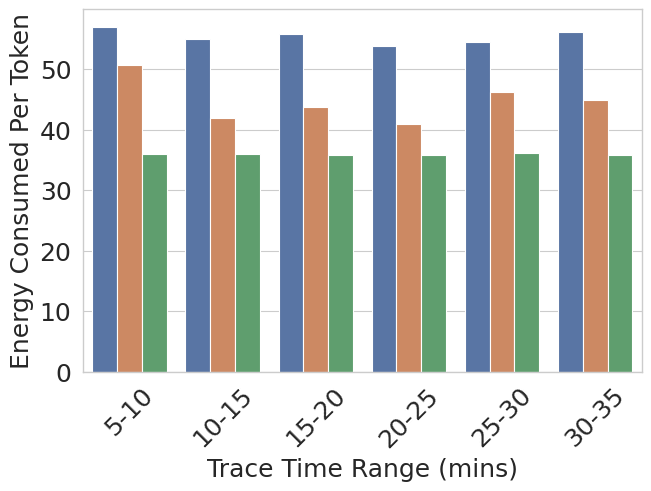

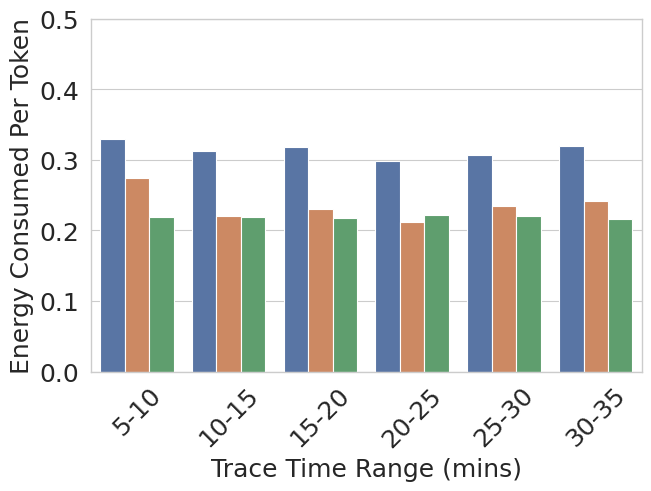

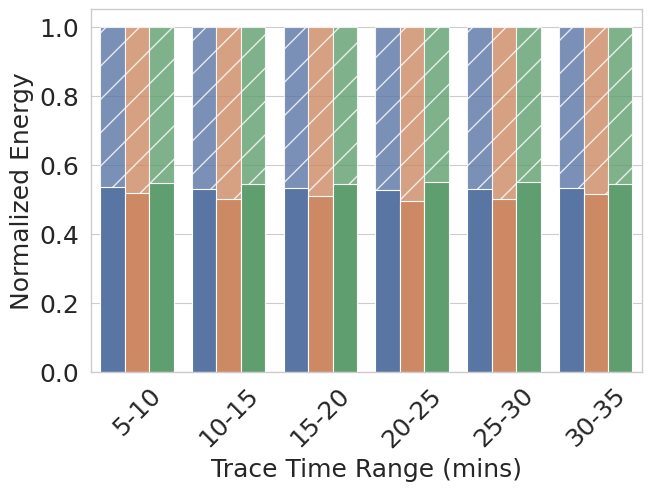

In [13]:
path = "/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/85_percent_char_balance/metrics.csv"
df_results = pd.read_csv(path)

# Create a mapping for renaming expr_dir values
rename_mapping = {
    'DISTSERVE_R5_JAN3_REAL_P85_6': 'Distserve 85',
    'DISTSERVE_R5_JAN3_REAL_P85_5': 'Distserve 70',
    'DISTSERVE_R5_JAN3_REAL_P85_4': 'Distserve 55',
    'DISTSERVE_R5_JAN3_REAL_P85_3': 'Distserve 40',
    'DISTSERVE_R5_JAN3_REAL_P85_2': 'Distserve 25',
    'DISTSERVE_R5_JAN3_REAL_P85_1': 'Distserve 10',
    'OURS_R5_JAN3_REAL_P85_6': 'Min Energy 85',
    'OURS_R5_JAN3_REAL_P85_5': 'Min Energy 70',
    'OURS_R5_JAN3_REAL_P85_4': 'Min Energy 55',
    'OURS_R5_JAN3_REAL_P85_3': 'Min Energy 40',
    'OURS_R5_JAN3_REAL_P85_2': 'Min Energy 25',
    'OURS_R5_JAN3_REAL_P85_1': 'Min Energy 10',
    'OURS_R5_JAN3_REAL_P85_6_DVFS': 'Min Energy + DVFS 85',
    'OURS_R5_JAN3_REAL_P85_5_DVFS': 'Min Energy + DVFS 70',
    'OURS_R5_JAN3_REAL_P85_4_DVFS': 'Min Energy + DVFS 55',
    'OURS_R5_JAN3_REAL_P85_3_DVFS': 'Min Energy + DVFS 40',
    'OURS_R5_JAN3_REAL_P85_2_DVFS': 'Min Energy + DVFS 25',
    'OURS_R5_JAN3_REAL_P85_1_DVFS': 'Min Energy + DVFS 10',
    'OURS_R5_JAN3_REAL_P85_6_DVFS_W': 'Min Energy + DVFS 85',
    'OURS_R5_JAN3_REAL_P85_5_DVFS_W': 'Min Energy + DVFS 70',
    'OURS_R5_JAN3_REAL_P85_4_DVFS_W': 'Min Energy + DVFS 55',
    'OURS_R5_JAN3_REAL_P85_3_DVFS_W': 'Min Energy + DVFS 40',
    'OURS_R5_JAN3_REAL_P85_2_DVFS_W': 'Min Energy + DVFS 25',
    'OURS_R5_JAN3_REAL_P85_1_DVFS_W': 'Min Energy + DVFS 10',
}

df_results = df_results[~df_results['expr_dir'].isin([
    'OURS_R5_JAN3_REAL_P85_6_DVFS', 'OURS_R5_JAN3_REAL_P85_5_DVFS',
    'OURS_R5_JAN3_REAL_P85_4_DVFS', 'OURS_R5_JAN3_REAL_P85_3_DVFS',
    'OURS_R5_JAN3_REAL_P85_2_DVFS', 'OURS_R5_JAN3_REAL_P85_1_DVFS'
])]
# Replace values in expr_dir column
df_results['expr_dir'] = df_results['expr_dir'].replace(rename_mapping)

df_results = df_results[df_results["instance"] == "total"]

# Sort the dataframe by extracting the numeric suffix from expr_dir
df_results['sort_key'] = df_results['expr_dir'].str.extract('(\d+)$')[0].fillna(0).astype(int)
df_results = df_results.sort_values('sort_key')

# Extract RPS and name from expr_dir
df_results['rps'] = df_results['expr_dir'].str.extract('(\d+)$')[0].astype(int)
df_results['name'] = df_results['expr_dir'].str.replace('\s+\d+$', '', regex=True)
# Set the order of the categories
df_results['name'] = pd.Categorical(df_results['name'], categories=['Distserve', 'Min Energy', 'Min Energy + DVFS'], ordered=True)
df_results = df_results.sort_values(['rps', 'name'])

sns.set_theme(context="paper", style="whitegrid")
plt.figure(constrained_layout=True)
ax = sns.barplot(
    x="rps", 
    y="prefill_energy_per_token", 
    hue="name", 
    data=df_results, 
    dodge=True,
    # hatch='/', # Add hatch pattern to the bars
    # alpha=0.8,       # Lighter color for Prefill
)

# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=18)
ax.set_ylabel('Energy Consumed Per Token', fontsize=18)
ax.set_xticks([0, 1, 2, 3, 4, 5])  # Set the positions of the x-axis ticks
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=18, rotation=45, ha='center')
# ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x * 1e-6:.1f}'))
# plt.ylim(0, 1.5e6)
ax.tick_params(axis='y', labelsize=18)  # Adjust the font size of y-axis tick labels
ax.legend_.remove()
plt.savefig("figs/plot_energy_85p_prefill.svg", format="svg")

sns.set_theme(context="paper", style="whitegrid")
plt.figure(constrained_layout=True)
ax = sns.barplot(
    x="rps", 
    y="decode_energy_per_token", 
    hue="name", 
    data=df_results, 
    dodge=True
)

# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=18)
ax.set_ylabel('Energy Consumed Per Token', fontsize=18)
ax.set_xticks([0, 1, 2, 3, 4, 5])  # Set the positions of the x-axis ticks
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=18, rotation=45, ha='center')
ax.tick_params(axis='y', labelsize=18)  # Adjust the font size of y-axis tick labels
# ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x * 1e-6:.1f}'))
plt.ylim(0, 0.5)
ax.legend_.remove()
plt.savefig("figs/plot_energy_85p_decode.svg", format="svg")


df_results['total_norm'] = 1.0
df_results['decode_norm'] = df_results['energy_decode'] / df_results['energy_j']
sns.set_theme(context="paper", style="whitegrid")
plt.figure(constrained_layout=True)
ax = sns.barplot(
    x="rps", 
    y="total_norm", 
    hue="name", 
    data=df_results, 
    dodge=True,
    hatch='/', # Add hatch pattern to the bars
    alpha=0.8,       # Lighter color for Prefill
)
sns.barplot(
    x="rps", 
    y="decode_norm", 
    hue="name", 
    data=df_results, 
    dodge=True,
    ax=ax
)
ax.set_xlabel('Trace Time Range (mins)', fontsize=18)
ax.set_ylabel('Normalized Energy', fontsize=18)
ax.set_xticks([0, 1, 2, 3, 4, 5])  # Set the positions of the x-axis ticks
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=18, rotation=45, ha='center')
ax.tick_params(axis='y', labelsize=18)  # Adjust the font size of y-axis tick labels
ax.legend_.remove()
plt.savefig("figs/plot_energy_85p_percent.svg", format="svg")

In [14]:
# Normalize energy with Distserve energy for both prefill and decode
df_results['prefill_energy_norm_D'] = df_results.apply(
    lambda row: 1 - row['prefill_energy_per_token'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'Distserve')
    ]['prefill_energy_per_token'].values[0],
    axis=1
)

df_results['decode_energy_norm_D'] = df_results.apply(
    lambda row: 1 - row['decode_energy_per_token'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'Distserve')
    ]['decode_energy_per_token'].values[0],
    axis=1
)

df_results['prefill_energy_norm_M'] = df_results.apply(
    lambda row: 1 - row['prefill_energy_per_token'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'Min Energy')
    ]['prefill_energy_per_token'].values[0],
    axis=1
)

df_results['decode_energy_norm_M'] = df_results.apply(
    lambda row: 1 - row['decode_energy_per_token'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'Min Energy')
    ]['decode_energy_per_token'].values[0],
    axis=1
)
df_results[['expr_dir', 'prefill_energy_per_token', 'decode_energy_per_token', 'prefill_energy_norm_M', 'decode_energy_norm_M', 'prefill_energy_norm_D', 'decode_energy_norm_D']]

,expr_dir,prefill_energy_per_token,decode_energy_per_token,prefill_energy_norm_M,decode_energy_norm_M,prefill_energy_norm_D,decode_energy_norm_D
6,Distserve 10,57.068230,0.328928,-0.123859,-0.201159,0.000000,0.000000
48,Min Energy 10,50.778817,0.273842,0.000000,0.000000,0.110209,0.167471
62,Min Energy + DVFS 10,36.067490,0.218367,0.289714,0.202580,0.367994,0.336125
13,Distserve 25,54.995195,0.313146,-0.309962,-0.416726,0.000000,0.000000
69,Min Energy 25,41.982272,0.221035,0.000000,0.000000,0.236619,0.294147
83,Min Energy + DVFS 25,35.946864,0.218594,0.143761,0.011042,0.346364,0.301941
20,Distserve 40,55.869724,0.317842,-0.277584,-0.376356,0.000000,0.000000
90,Min Energy 40,43.730760,0.230930,0.000000,0.000000,0.217273,0.273444
104,Min Energy + DVFS 40,35.889836,0.217984,0.179300,0.056060,0.357616,0.314175
27,Distserve 55,53.772511,0.299049,-0.311925,-0.407863,0.000000,0.000000


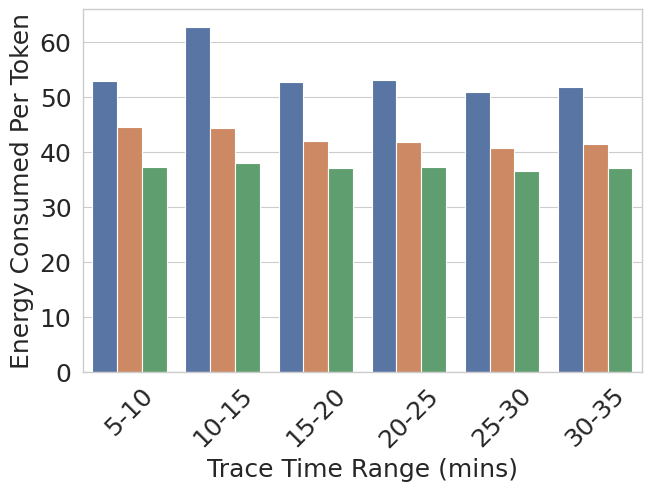

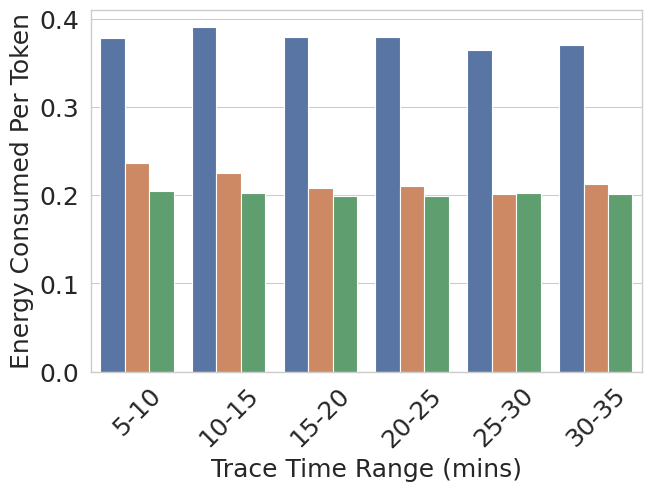

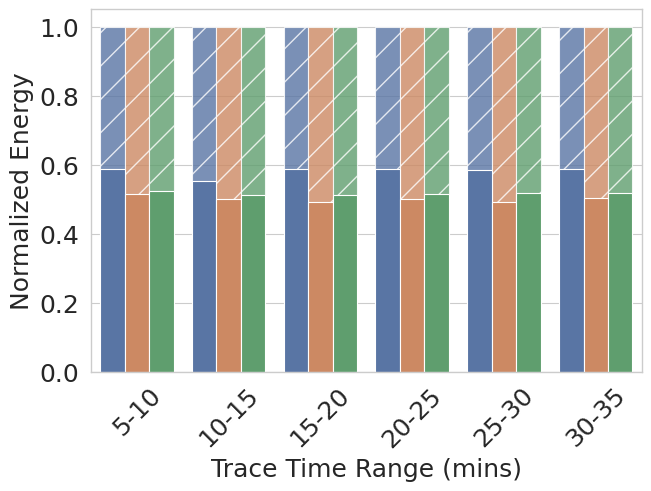

In [15]:
path = "/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/67_percent_char_balance/metrics.csv"
df_results = pd.read_csv(path)

# Create a mapping for renaming expr_dir values
rename_mapping = {
    'DISTSERVE_R5_JAN3_OLD_P90_6': 'Distserve 85',
    'DISTSERVE_R5_JAN3_OLD_P90_5': 'Distserve 70',
    'DISTSERVE_R5_JAN3_OLD_P90_4': 'Distserve 55',
    'DISTSERVE_R5_JAN3_OLD_P90_3': 'Distserve 40',
    'DISTSERVE_R5_JAN3_OLD_P90_2': 'Distserve 25',
    'DISTSERVE_R5_JAN3_OLD_P90_1': 'Distserve 10',
    'OURS_R5_JAN3_OLD_P90_6': 'Min Energy 85',
    'OURS_R5_JAN3_OLD_P90_5': 'Min Energy 70',
    'OURS_R5_JAN3_OLD_P90_4': 'Min Energy 55',
    'OURS_R5_JAN3_OLD_P90_3': 'Min Energy 40',
    'OURS_R5_JAN3_OLD_P90_2': 'Min Energy 25',
    'OURS_R5_JAN3_OLD_P90_1': 'Min Energy 10',
    'OURS_R5_JAN3_OLD_P90_6_DVFS': 'Min Energy + DVFS 85',
    'OURS_R5_JAN3_OLD_P90_5_DVFS': 'Min Energy + DVFS 70',
    'OURS_R5_JAN3_OLD_P90_4_DVFS': 'Min Energy + DVFS 55',
    'OURS_R5_JAN3_OLD_P90_3_DVFS': 'Min Energy + DVFS 40',
    'OURS_R5_JAN3_OLD_P90_2_DVFS': 'Min Energy + DVFS 25',
    'OURS_R5_JAN3_OLD_P90_1_DVFS': 'Min Energy + DVFS 10',
    'OURS_R5_JAN3_OLD_P90_1_DVFS_W': 'Min Energy + DVFS 10',
    'OURS_R5_JAN3_OLD_P90_2_DVFS_W': 'Min Energy + DVFS 25',
    'OURS_R5_JAN3_OLD_P90_3_DVFS_W': 'Min Energy + DVFS 40',
    'OURS_R5_JAN3_OLD_P90_4_DVFS_W': 'Min Energy + DVFS 55',
    'OURS_R5_JAN3_OLD_P90_5_DVFS_W': 'Min Energy + DVFS 70',
    'OURS_R5_JAN3_OLD_P90_6_DVFS_W': 'Min Energy + DVFS 85',
}

df_results = df_results[~df_results['expr_dir'].isin([
    'OURS_R5_JAN3_OLD_P90_6_DVFS', 'OURS_R5_JAN3_OLD_P90_5_DVFS',
    'OURS_R5_JAN3_OLD_P90_4_DVFS', 'OURS_R5_JAN3_OLD_P90_3_DVFS',
    'OURS_R5_JAN3_OLD_P90_2_DVFS', 'OURS_R5_JAN3_OLD_P90_1_DVFS'
])]

# Replace values in expr_dir column
df_results['expr_dir'] = df_results['expr_dir'].replace(rename_mapping)
df_results = df_results[~df_results['expr_dir'].str.contains('OURS_R5_JAN3_OLD_P90_.*_DVFS', regex=True)]

df_results = df_results[df_results["instance"] == "total"]

# Sort the dataframe by extracting the numeric suffix from expr_dir
df_results['sort_key'] = df_results['expr_dir'].str.extract('(\d+)$')[0].fillna(0).astype(int)
df_results = df_results.sort_values('sort_key')

# Extract RPS and name from expr_dir
df_results['rps'] = df_results['expr_dir'].str.extract('(\d+)$')[0].astype(int)
df_results['name'] = df_results['expr_dir'].str.replace('\s+\d+$', '', regex=True)
# Set the order of the categories
df_results['name'] = pd.Categorical(df_results['name'], categories=['Distserve', 'Min Energy', 'Min Energy + DVFS'], ordered=True)
df_results = df_results.sort_values(['rps', 'name'])

sns.set_theme(context="paper", style="whitegrid")
plt.figure(constrained_layout=True)
ax = sns.barplot(
    x="rps", 
    y="prefill_energy_per_token", 
    hue="name", 
    data=df_results, 
    dodge=True,
    # hatch='/', # Add hatch pattern to the bars
    # alpha=0.8,       # Lighter color for Prefill
)

# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=18)
ax.set_ylabel('Energy Consumed Per Token', fontsize=18)
ax.set_xticks([0, 1, 2, 3, 4, 5])  # Set the positions of the x-axis ticks
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=18, rotation=45, ha='center')
# ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x * 1e-6:.1f}'))
# plt.ylim(0, 1.5e6)
ax.tick_params(axis='y', labelsize=18)  # Adjust the font size of y-axis tick labels
ax.legend_.remove()
plt.savefig("figs/plot_energy_67p_prefill.svg", format="svg")

sns.set_theme(context="paper", style="whitegrid")
plt.figure(constrained_layout=True)
ax = sns.barplot(
    x="rps", 
    y="decode_energy_per_token", 
    hue="name", 
    data=df_results, 
    dodge=True
)

# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=18)
ax.set_ylabel('Energy Consumed Per Token', fontsize=18)
ax.set_xticks([0, 1, 2, 3, 4, 5])  # Set the positions of the x-axis ticks
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=18, rotation=45, ha='center')
ax.tick_params(axis='y', labelsize=18)  # Adjust the font size of y-axis tick labels
# ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x * 1e-6:.1f}'))
# plt.ylim(0, 1.5e6)
ax.legend_.remove()
plt.savefig("figs/plot_energy_67p_decode.svg", format="svg")


df_results['total_norm'] = 1.0
df_results['decode_norm'] = df_results['energy_decode'] / df_results['energy_j']
sns.set_theme(context="paper", style="whitegrid")
plt.figure(constrained_layout=True)
ax = sns.barplot(
    x="rps", 
    y="total_norm", 
    hue="name", 
    data=df_results, 
    dodge=True,
    hatch='/', # Add hatch pattern to the bars
    alpha=0.8,       # Lighter color for Prefill
)
sns.barplot(
    x="rps", 
    y="decode_norm", 
    hue="name", 
    data=df_results, 
    dodge=True,
    ax=ax
)
ax.set_xlabel('Trace Time Range (mins)', fontsize=18)
ax.set_ylabel('Normalized Energy', fontsize=18)
ax.set_xticks([0, 1, 2, 3, 4, 5])  # Set the positions of the x-axis ticks
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=18, rotation=45, ha='center')
ax.tick_params(axis='y', labelsize=18)  # Adjust the font size of y-axis tick labels
ax.legend_.remove()
plt.savefig("figs/plot_energy_67p_percent.svg", format="svg")

In [16]:
# Normalize energy with Distserve energy for both prefill and decode
df_results['prefill_energy_norm_D'] = df_results.apply(
    lambda row: 1 - row['prefill_energy_per_token'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'Distserve')
    ]['prefill_energy_per_token'].values[0],
    axis=1
)

df_results['decode_energy_norm_D'] = df_results.apply(
    lambda row: 1 - row['decode_energy_per_token'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'Distserve')
    ]['decode_energy_per_token'].values[0],
    axis=1
)

df_results['prefill_energy_norm_M'] = df_results.apply(
    lambda row: 1 - row['prefill_energy_per_token'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'Min Energy')
    ]['prefill_energy_per_token'].values[0],
    axis=1
)

df_results['decode_energy_norm_M'] = df_results.apply(
    lambda row: 1 - row['decode_energy_per_token'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'Min Energy')
    ]['decode_energy_per_token'].values[0],
    axis=1
)
df_results[['expr_dir', 'prefill_energy_per_token', 'decode_energy_per_token', 'prefill_energy_norm_M', 'decode_energy_norm_M', 'prefill_energy_norm_D', 'decode_energy_norm_D']]

,expr_dir,prefill_energy_per_token,decode_energy_per_token,prefill_energy_norm_M,decode_energy_norm_M,prefill_energy_norm_D,decode_energy_norm_D
5,Distserve 10,52.833107,0.378395,-0.189153,-0.603856,0.000000,0.000000
43,Min Energy 10,44.429178,0.235928,0.000000,0.000000,0.159066,0.376503
57,Min Energy + DVFS 10,37.312327,0.205063,0.160184,0.130823,0.293770,0.458071
12,Distserve 25,62.788478,0.390556,-0.419055,-0.735422,0.000000,0.000000
64,Min Energy 25,44.246693,0.225050,0.000000,0.000000,0.295306,0.423771
78,Min Energy + DVFS 25,37.881842,0.202016,0.143849,0.102351,0.396675,0.482749
18,Distserve 40,52.727407,0.379710,-0.257943,-0.827874,0.000000,0.000000
85,Min Energy 40,41.915575,0.207733,0.000000,0.000000,0.205051,0.452916
99,Min Energy + DVFS 40,37.093853,0.199397,0.115034,0.040130,0.296498,0.474871
24,Distserve 55,52.981524,0.379188,-0.265549,-0.804039,0.000000,0.000000
